# Construction de la série annuelle des indicateurs clés

**Projet data PSL-CFX** — Hôpitaux universitaires Pitié-Salpêtrière / Charles-Foix

Ce notebook assemble, à partir des données extraites des rapports annuels
(`data/raw/`), une série temporelle annuelle propre au format long. Elle servira
de base au travail de prévision.

Le résultat est écrit dans `data/processed/serie_annuelle.csv` avec les colonnes :

| Colonne | Contenu |
|---------|---------|
| `ANNEE` | Année de l'observation |
| `INDICATEUR` | Nom normalisé de la série |
| `VALEUR` | Valeur au niveau du groupe hospitalier (colonne `TOTAL` des sources) |
| `COMPARABLE` | `True` si les valeurs de la série sont comparables d'une année à l'autre |

> **Les fichiers de `data/raw/` ne sont jamais modifiés** : ce notebook les lit
> uniquement en lecture seule.

## 1. Chargement des données sources

In [1]:
# Imports et localisation du projet
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

%matplotlib inline


def trouver_racine(depart: Path) -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant requirements.txt."""
    for dossier in [depart, *depart.parents]:
        if (dossier / "requirements.txt").exists():
            return dossier
    raise RuntimeError("Racine du projet introuvable")


RACINE = trouver_racine(Path.cwd())
DOSSIER_BRUT = RACINE / "data" / "raw"
DOSSIER_TRAITE = RACINE / "data" / "processed"
DOSSIER_TRAITE.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", RACINE)

Racine du projet : d:\Smart Care\projet-data-pslcfx


In [2]:
# Lecture des deux fichiers utiles à cette étape
activite = pd.read_csv(DOSSIER_BRUT / "activite.csv", encoding="utf-8")
capacite = pd.read_csv(DOSSIER_BRUT / "capacite.csv", encoding="utf-8")

for nom, df in [("activite.csv", activite), ("capacite.csv", capacite)]:
    annees = ", ".join(str(a) for a in sorted(df["ANNEE"].unique()))
    print(f"{nom:15s} {len(df):3d} lignes | années : {annees}")

activite.csv     65 lignes | années : 2011, 2012, 2015, 2016
capacite.csv     33 lignes | années : 2012, 2015, 2016


## 2. Sélection des séries

Chaque série est décrite par les filtres à appliquer à son fichier source. On
retient systématiquement la colonne `TOTAL`, c'est-à-dire le niveau du groupe
hospitalier, afin d'éviter les nombreuses cellules `PSL`/`CFX` vides du rapport
2016 (voir la section « Pièges de comparabilité » du README).

Les urgences font l'objet d'un traitement séparé, expliqué plus bas.

In [3]:
# Description déclarative des séries à extraire.
#   indicateur : valeur exacte attendue dans la colonne INDICATEUR
#   contient   : filtre par sous-chaîne sur SOUS_INDICATEUR (libellés variables)
#   egal       : filtre par égalité stricte sur SOUS_INDICATEUR
SERIES = [
    {"nom": "Séjours hospitalisation complète", "source": "activite",
     "indicateur": "Séjours MCO", "contient": "complète", "unite": "Séjours"},
    {"nom": "Séjours ambulatoires", "source": "activite",
     "indicateur": "Séjours MCO", "contient": "Ambulatoire", "unite": "Séjours"},
    {"nom": "Consultations externes", "source": "activite",
     "indicateur": "Consultations externes", "unite": "Consultations"},
    {"nom": "Transplantations", "source": "activite",
     "indicateur": "Transplantations", "egal": "Total", "unite": "Greffes"},
    {"nom": "Lits installés", "source": "capacite",
     "indicateur": "Lits installés", "unite": "Lits"},
    {"nom": "Journées SSR", "source": "activite",
     "indicateur": "Journées", "egal": "SSR", "unite": "Journées"},
    {"nom": "Journées SLD", "source": "activite",
     "indicateur": "Journées", "egal": "SLD", "unite": "Journées"},
    {"nom": "Journées PSY", "source": "activite",
     "indicateur": "Journées", "egal": "PSY", "unite": "Journées"},
]

SOURCES = {"activite": activite, "capacite": capacite}


def extraire(spec: dict) -> pd.DataFrame:
    """Applique les filtres d'une série et renvoie ANNEE / INDICATEUR / VALEUR."""
    df = SOURCES[spec["source"]]
    masque = df["INDICATEUR"] == spec["indicateur"]

    if "contient" in spec:
        masque &= df["SOUS_INDICATEUR"].str.contains(spec["contient"], na=False)
    if "egal" in spec:
        masque &= df["SOUS_INDICATEUR"] == spec["egal"]

    extrait = df.loc[masque, ["ANNEE", "TOTAL"]].rename(columns={"TOTAL": "VALEUR"})
    extrait.insert(1, "INDICATEUR", spec["nom"])
    return extrait.sort_values("ANNEE").reset_index(drop=True)


series_comparables = pd.concat([extraire(s) for s in SERIES], ignore_index=True)
series_comparables["COMPARABLE"] = True

# Contrôle visuel : une ligne par série, avec les années effectivement trouvées
for nom, groupe in series_comparables.groupby("INDICATEUR", sort=False):
    annees = ", ".join(str(a) for a in groupe["ANNEE"])
    print(f"{nom:35s} {len(groupe)} point(s) : {annees}")

Séjours hospitalisation complète    4 point(s) : 2011, 2012, 2015, 2016
Séjours ambulatoires                4 point(s) : 2011, 2012, 2015, 2016
Consultations externes              4 point(s) : 2011, 2012, 2015, 2016
Transplantations                    3 point(s) : 2012, 2015, 2016
Lits installés                      3 point(s) : 2012, 2015, 2016
Journées SSR                        4 point(s) : 2011, 2012, 2015, 2016
Journées SLD                        4 point(s) : 2011, 2012, 2015, 2016
Journées PSY                        4 point(s) : 2011, 2012, 2015, 2016


### Cas particulier : les passages aux urgences

**Cette série n'est pas comparable d'une année à l'autre.** Les trois rapports ne
comptent pas la même chose sous le mot « urgences » :

| Année | Valeur publiée | Périmètre réel |
|-------|----------------|----------------|
| 2011 | 83 002 | Pitié-Salpêtrière seule, **hors** urgences dentaires |
| 2012 | 85 993 | Pitié-Salpêtrière seule, **hors** urgences dentaires |
| 2015 | 121 721 | SAU 59 072 **+** urgences dentaires 62 649 |
| 2016 | 127 678 | Périmètre encore différent (dont 61 651 urgences spécialisées) |

Prendre les valeurs publiées telles quelles ferait apparaître une progression de
+41,5 % entre 2012 et 2015 qui n'est qu'un **artefact de changement de périmètre**.

Pour se rapprocher d'une définition constante, on retient donc :

- **2011 et 2012** : les passages publiés, qui excluent déjà les urgences dentaires ;
- **2015** : le seul **SAU** (59 072), en écartant les 62 649 passages dentaires ;
- **2016** : **année écartée**, le rapport ne permettant pas d'isoler le SAU.

Même après ce retraitement, la comparabilité n'est pas garantie : on ignore si le
périmètre « passages » de 2011-2012 correspond exactement au SAU de 2015. La série
est donc marquée `COMPARABLE = False` et **ne doit pas servir de base à une
prévision**. Elle est conservée à titre documentaire, et c'est précisément ce
qui justifiera de recourir à des données publiques à pas fin pour la
modélisation — en l'occurrence les séries quotidiennes de la DREES.

In [4]:
# Les valeurs ne portent pas le même libellé selon l'année : on les prélève
# explicitement, ligne par ligne, plutôt que par un filtre générique.
PRELEVEMENTS_URGENCES = [
    (2011, "Passages"),      # PSL seule, hors dentaires
    (2012, "Passages"),      # PSL seule, hors dentaires
    (2015, "Passages SAU"),  # SAU seul, dentaires écartés
    # 2016 volontairement absente : le SAU n'y est pas isolable.
]

lignes_urgences = []
for annee, sous_indicateur in PRELEVEMENTS_URGENCES:
    masque = (
        (activite["ANNEE"] == annee)
        & (activite["INDICATEUR"] == "Urgences")
        & (activite["SOUS_INDICATEUR"] == sous_indicateur)
    )
    trouve = activite.loc[masque, "TOTAL"]
    # Garde-fou : on veut exactement une ligne, sinon la source a changé.
    assert len(trouve) == 1, f"Ligne urgences {annee} / {sous_indicateur} introuvable ou ambiguë"
    lignes_urgences.append({
        "ANNEE": annee,
        "INDICATEUR": "Urgences (SAU)",
        "VALEUR": float(trouve.iloc[0]),
        "COMPARABLE": False,
    })

serie_urgences = pd.DataFrame(lignes_urgences)
serie_urgences

,ANNEE,INDICATEUR,VALEUR,COMPARABLE
0,2011,Urgences (SAU),83002.0,False
1,2012,Urgences (SAU),85993.0,False
2,2015,Urgences (SAU),59072.0,False


## 3. Assemblage et écriture du fichier

In [5]:
# Assemblage des séries comparables et de la série urgences
serie_annuelle = pd.concat([series_comparables, serie_urgences], ignore_index=True)

serie_annuelle["ANNEE"] = serie_annuelle["ANNEE"].astype(int)
serie_annuelle["VALEUR"] = serie_annuelle["VALEUR"].astype(float)
serie_annuelle = (
    serie_annuelle[["ANNEE", "INDICATEUR", "VALEUR", "COMPARABLE"]]
    .sort_values(["INDICATEUR", "ANNEE"])
    .reset_index(drop=True)
)

destination = DOSSIER_TRAITE / "serie_annuelle.csv"
serie_annuelle.to_csv(destination, index=False, encoding="utf-8")

print(f"{len(serie_annuelle)} lignes écrites dans {destination.relative_to(RACINE)}")
serie_annuelle.head(10)

33 lignes écrites dans data\processed\serie_annuelle.csv


,ANNEE,INDICATEUR,VALEUR,COMPARABLE
0,2011,Consultations externes,633536.0,True
1,2012,Consultations externes,660958.0,True
2,2015,Consultations externes,607950.0,True
3,2016,Consultations externes,644602.0,True
4,2011,Journées PSY,34572.0,True
5,2012,Journées PSY,37200.0,True
6,2015,Journées PSY,51240.0,True
7,2016,Journées PSY,50690.0,True
8,2011,Journées SLD,104377.0,True
9,2012,Journées SLD,89494.0,True


## 4. Contrôles

Deux vérifications avant d'aller plus loin : aucune valeur manquante, et au moins
trois points par série (une série de moins de trois points ne permet aucune
lecture de tendance).

In [6]:
anomalies = []

# Contrôle 1 : aucune valeur vide
nb_vides = int(serie_annuelle["VALEUR"].isna().sum())
print(f"Valeurs manquantes : {nb_vides}")
if nb_vides:
    anomalies.append(f"{nb_vides} valeur(s) vide(s)")

# Contrôle 2 : au moins 3 points par série
print("\nNombre de points par série :")
for nom, groupe in serie_annuelle.groupby("INDICATEUR"):
    comparable = bool(groupe["COMPARABLE"].iloc[0])
    statut = "comparable" if comparable else "NON comparable"
    print(f"  {nom:35s} {len(groupe)} point(s)  [{statut}]")
    if len(groupe) < 3:
        anomalies.append(f"{nom} : {len(groupe)} point(s) seulement")

print()
if anomalies:
    print("ANOMALIES :", " | ".join(anomalies))
else:
    print("Tous les contrôles passent : aucune valeur vide, "
          "toutes les séries comptent au moins 3 points.")
    print("La série « Urgences (SAU) » compte bien 3 points, "
          "mais reste marquée non comparable.")

Valeurs manquantes : 0

Nombre de points par série :
  Consultations externes              4 point(s)  [comparable]
  Journées PSY                        4 point(s)  [comparable]
  Journées SLD                        4 point(s)  [comparable]
  Journées SSR                        4 point(s)  [comparable]
  Lits installés                      3 point(s)  [comparable]
  Séjours ambulatoires                4 point(s)  [comparable]
  Séjours hospitalisation complète    4 point(s)  [comparable]
  Transplantations                    3 point(s)  [comparable]
  Urgences (SAU)                      3 point(s)  [NON comparable]

Tous les contrôles passent : aucune valeur vide, toutes les séries comptent au moins 3 points.
La série « Urgences (SAU) » compte bien 3 points, mais reste marquée non comparable.


## 5. Tendances par indicateur

Un graphique par série. Les années 2013 et 2014 ne sont pas couvertes par les
rapports disponibles : l'écart entre 2012 et 2015 est donc visible sur l'axe des
abscisses, et il ne faut pas lire le segment qui les relie comme une évolution
continue.

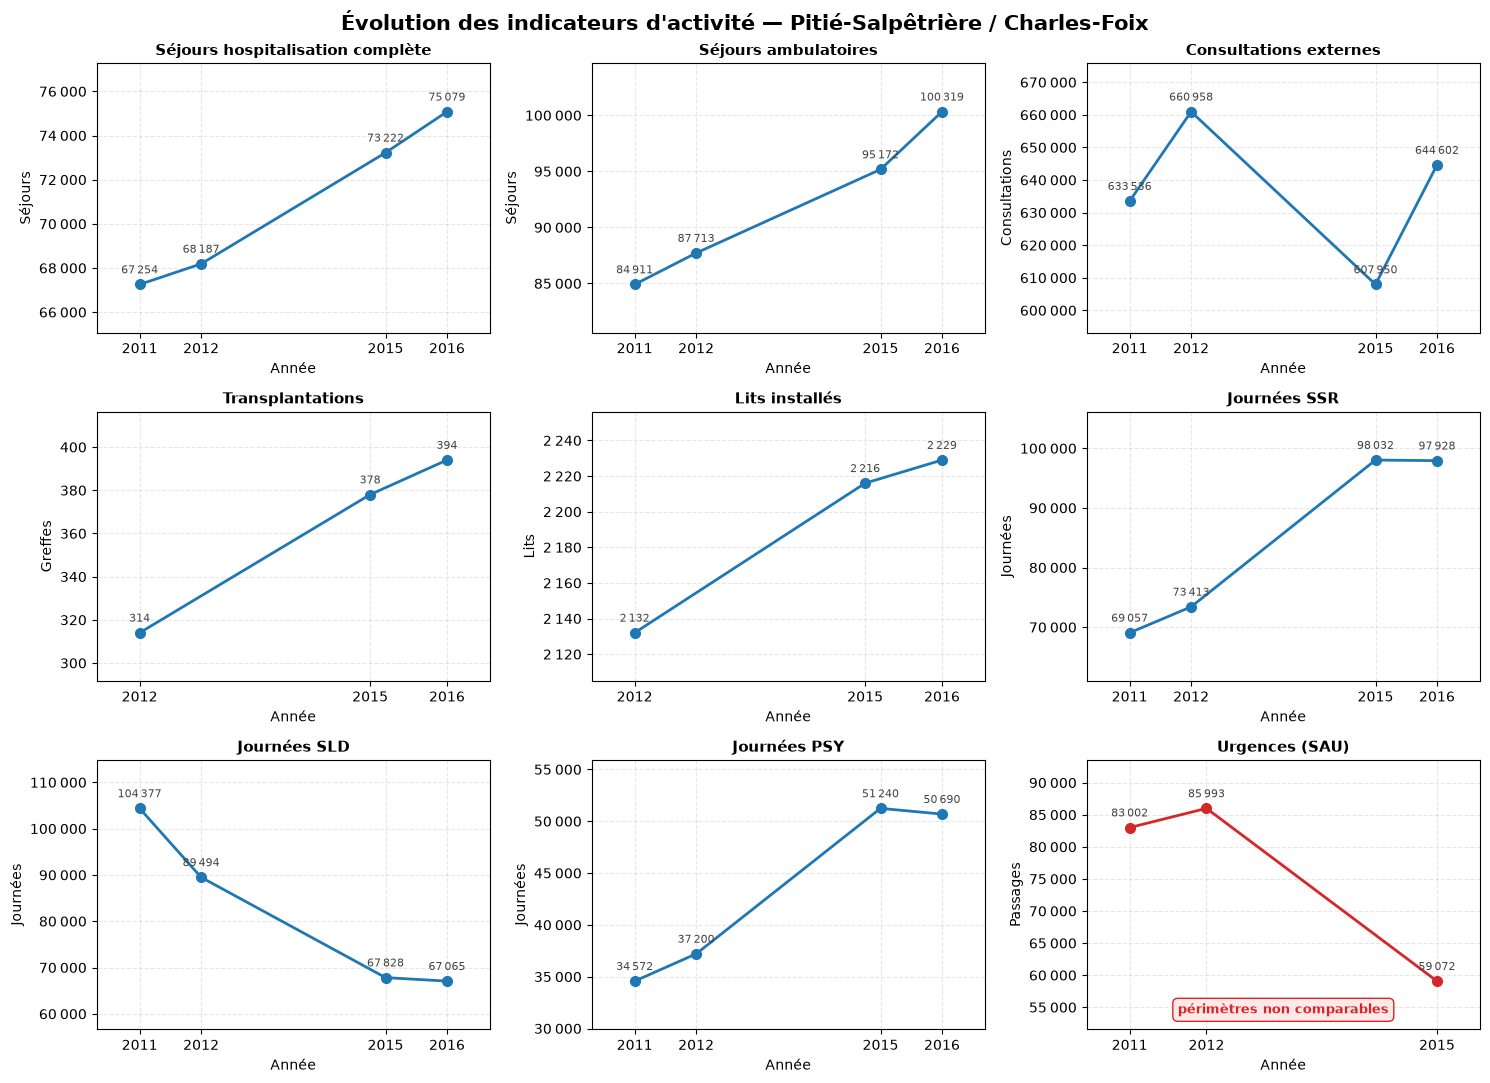

In [7]:
# Ordre d'affichage : les séries comparables, puis les urgences
ORDRE = [s["nom"] for s in SERIES] + ["Urgences (SAU)"]
UNITES = {s["nom"]: s["unite"] for s in SERIES}
UNITES["Urgences (SAU)"] = "Passages"

BLEU = "#1f77b4"
ROUGE = "#d62728"

# Séparateur de milliers à la française (espace insécable)
formateur_milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle(
    "Évolution des indicateurs d'activité — Pitié-Salpêtrière / Charles-Foix",
    fontsize=15, fontweight="bold",
)

for ax, nom in zip(axes.flat, ORDRE):
    groupe = serie_annuelle[serie_annuelle["INDICATEUR"] == nom].sort_values("ANNEE")
    comparable = bool(groupe["COMPARABLE"].iloc[0])
    couleur = BLEU if comparable else ROUGE

    ax.plot(groupe["ANNEE"], groupe["VALEUR"], marker="o", markersize=7,
            linewidth=2, color=couleur)

    ax.set_title(nom, fontsize=11, fontweight="bold")
    ax.set_xlabel("Année")
    ax.set_ylabel(UNITES[nom])
    ax.set_xticks(groupe["ANNEE"].tolist())
    ax.yaxis.set_major_formatter(formateur_milliers)
    ax.grid(alpha=0.3, linestyle="--")
    # Marges généreuses pour que les valeurs annotées ne soient pas rognées
    ax.margins(x=0.14, y=0.28)

    # Valeur annotée au-dessus de chaque point
    for annee, valeur in zip(groupe["ANNEE"], groupe["VALEUR"]):
        ax.annotate(f"{valeur:,.0f}".replace(",", "\u202f"),
                    xy=(annee, valeur), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color="#444444")

    # Avertissement explicite sur la série non comparable
    if not comparable:
        ax.text(0.5, 0.06, "périmètres non comparables",
                transform=ax.transAxes, ha="center", fontsize=9,
                color=ROUGE, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffe8e8",
                          edgecolor=ROUGE, linewidth=1))

plt.tight_layout()
plt.show()

## 6. Conclusion

**Le virage ambulatoire est engagé, mais lent.** Les séjours ambulatoires
progressent de +18 % entre 2011 et 2016 (84 911 → 100 319) contre +12 % pour
l'hospitalisation complète (67 254 → 75 079) ; la part de l'ambulatoire dans les
séjours MCO ne gagne qu'un point et demi, de 55,8 % à 57,2 %.

**Les consultations externes stagnent.** Elles passent de 633 536 à 644 602
(+1,7 % en cinq ans), avec un creux marqué en 2015 (607 950) suivi d'un rebond :
sur si peu de points, on ne peut pas trancher entre une rupture réelle et un
simple changement de comptage.

**Charles-Foix reconvertit ses lits de longue durée en soins de suite.** Les
journées SLD chutent de 35 % (104 377 → 67 065) pendant que les journées SSR
bondissent de 42 % (69 057 → 97 928). Le mouvement vient presque entièrement de
Charles-Foix (SLD −40 % entre 2011 et 2015, contre −5 % à la Pitié-Salpêtrière) et
se confirme dans la capacité : 248 lits SLD en 2012 pour 189 en 2015, quand les
lits SSR passent de 209 à 275.

**L'activité de recours croît plus vite que les moyens.** Les transplantations
gagnent 25 % (314 → 394) et les journées de psychiatrie 47 %, pour un parc de lits
quasi stable (+4,5 %, 2 132 → 2 229) : le groupe absorbe des cas plus lourds à
capacité constante.

**Les urgences restent inexploitables pour une prévision.** Même retraitée, la
série ne compte que trois points sur des périmètres incertains. La modélisation
devra s'appuyer sur les données publiques de la DREES, dont le pas quotidien et
l'historique long permettent d'estimer une saisonnalité — ce que quatre points
annuels, dont deux années manquantes, ne permettront jamais.